In [10]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict


In [11]:
class BatterState(TypedDict):

    runs : int
    balls : int
    fours : int
    sixes : int

    sr : float
    boundary_pr : float
    bpb : float
    

In [15]:
def cal_sr(state: BatterState) -> BatterState:

    balls = state["balls"]
    runs = state["runs"]

    sr = (runs / balls) * 100

    return {"sr" : sr}


def cal_bp(state: BatterState) -> BatterState:

    runs = state["runs"]
    fours = state["fours"]
    sixes = state["sixes"]

    boundary_runs = (sixes * 6) + (fours * 4)

    boundary_pr = (boundary_runs / runs) * 100

    return {"boundary_pr" : boundary_pr}


def cal_bpb(state: BatterState) -> BatterState:

    balls = state["balls"]
    fours = state["fours"]
    sixes = state["sixes"]

    bpb = balls / (fours + sixes)

    return {"bpb" : bpb}

In [16]:
graph = StateGraph(BatterState)

graph.add_node("cal_sr",cal_sr)
graph.add_node("cal_bp",cal_bp)
graph.add_node("cal_bpb",cal_bpb)

graph.add_edge(START, "cal_sr")
graph.add_edge(START, "cal_bp")
graph.add_edge(START, "cal_bpb")
graph.add_edge("cal_sr", END)
graph.add_edge("cal_bp", END)
graph.add_edge("cal_bpb", END)

workflow = graph.compile()

In [17]:
# execute the graph
initial_state = {"runs" : 200, "balls" : 150, "fours" : 10, "sixes" : 10}

final_state = workflow.invoke(initial_state)

print(final_state)

{'runs': 200, 'balls': 150, 'fours': 10, 'sixes': 10, 'sr': 133.33333333333331, 'boundary_pr': 50.0, 'bpb': 7.5}


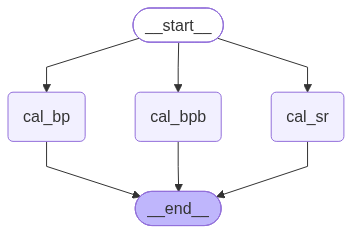

In [18]:
workflow